In [408]:
import pandas as pd
import numpy as np

In [409]:
volunteer = pd.read_csv('/content/Housing Price Prediction Data.csv')
volunteer.head()


,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4.0,1,Rural,1969,215355.2836
1,2459,3.0,2,Rural,1980,195014.2216
2,1860,2.0,1,Suburb,1970,306891.0121
3,2294,2.0,1,Urban,1996,206786.7872
4,2130,5.0,2,Suburb,2001,272436.2391


In [410]:
volunteer.shape

(3502, 6)

**Removing null values**

In [411]:
volunteer.isnull().sum()

,0
SquareFeet,0
Bedrooms,35
Bathrooms,0
Neighborhood,0
YearBuilt,0
Price,0


In [412]:
volunteer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3502 entries, 0 to 3501
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    3502 non-null   int64  
 1   Bedrooms      3467 non-null   float64
 2   Bathrooms     3502 non-null   int64  
 3   Neighborhood  3502 non-null   object 
 4   YearBuilt     3502 non-null   int64  
 5   Price         3502 non-null   float64
dtypes: float64(2), int64(3), object(1)
memory usage: 164.3+ KB


In [413]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(missing_values=np.nan, strategy='median')

impute.fit(volunteer[['Bedrooms']])

volunteer['Bedrooms'] = impute.transform(volunteer[['Bedrooms']])

In [414]:
volunteer.isnull().sum()

,0
SquareFeet,0
Bedrooms,0
Bathrooms,0
Neighborhood,0
YearBuilt,0
Price,0


**removing duplicate rows (if present),here we can see no duplicate row present**

In [415]:
volunteer.duplicated().sum()

0

**handling categorical variables, one-hot encoding**

In [416]:
volunteer['Neighborhood'].unique()

array(['Rural', 'Suburb', 'Urban'], dtype=object)

In [418]:

volunteer = pd.get_dummies(volunteer,columns=['Neighborhood'],dtype='int')

volunteer.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4.0,1,1969,215355.2836,1,0,0
1,2459,3.0,2,1980,195014.2216,1,0,0
2,1860,2.0,1,1970,306891.0121,0,1,0
3,2294,2.0,1,1996,206786.7872,0,0,1
4,2130,5.0,2,2001,272436.2391,0,1,0


** Removing 1-2 variables using correlation as feature selection**

In [419]:
volunteer_corr = volunteer.corr()
volunteer_corr.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
SquareFeet,1.000000,-0.003843,-0.020497,0.009925,0.743367,0.004047,0.003710,-0.007835
Bedrooms,-0.003843,1.000000,0.036234,0.010835,0.070281,0.012929,0.007770,-0.020919
Bathrooms,-0.020497,0.036234,1.000000,0.025003,0.033923,0.039540,-0.002451,-0.037575
YearBuilt,0.009925,0.010835,0.025003,1.000000,0.009422,0.000280,0.010803,-0.011162
Price,0.743367,0.070281,0.033923,0.009422,1.000000,0.004346,-0.007145,0.002794


 **Corelation Heatmap before removing a feature**



<Axes: >

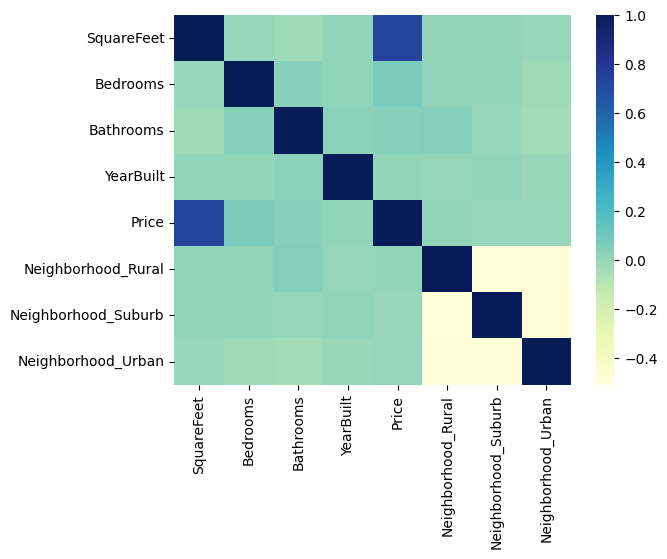

In [420]:
import seaborn as sns
sns.heatmap(volunteer_corr, cmap = 'YlGnBu')

In [431]:
selected_corelation=volunteer.drop(['SquareFeet',],axis=1)

**Heatmap after removing the feature**

<Axes: >

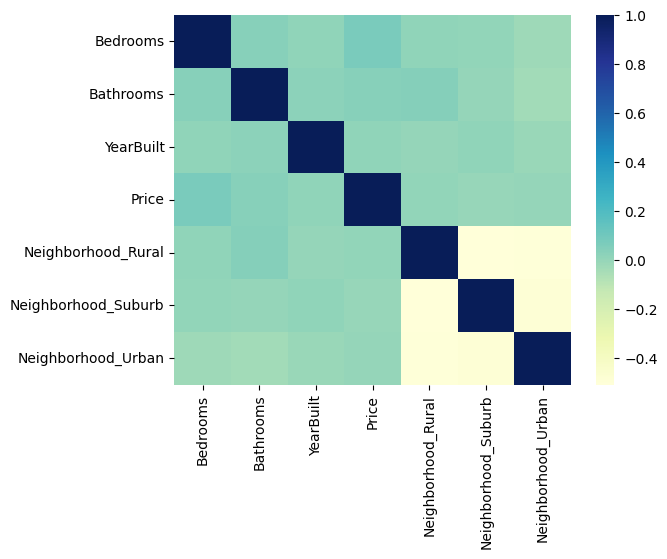

In [432]:
import seaborn as sns
house_price_corr=selected_corelation.corr()
sns.heatmap(house_price_corr, cmap = 'YlGnBu')

** Feature scaling**

accuracy without scaling


In [436]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
knn=LinearRegression()

knn.fit(X_train, y_train)
y_prediction=knn.predict(X_test)
print("Test set accuracy: {:.2f}".format(r2_score(y_test,y_prediction)))

Test set accuracy: 0.54


Using MinMax Scaler


In [441]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
features = ['Price']
volunteer[features] = scaler.fit_transform(volunteer[features])
x=volunteer.drop('Price',axis=1)
y=volunteer['Price']
X_train, X_test, y_train, y_test = train_test_split(x, y,random_state=1)
knn.fit(X_train, y_train)
y_prediction=knn.predict(X_test)
print("Test set accuracy: {:.2f}".format(r2_score(y_test,y_prediction)))

Test set accuracy: 0.54


Using StandardScaler


In [442]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# learning an SVM on the scaled training data
knn.fit(X_train_scaled, y_train)

# scoring on the scaled test set
y_prediction=knn.predict(X_test_scaled)
print("Test set accuracy: {:.2f}".format(r2_score(y_test,y_prediction)))

Test set accuracy: 0.54
